In [16]:
import pandas as pd

df = pd.read_csv("train.csv")

print(df.head())
print(df.shape)

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [3]:
# Fill missing values with median (better than dropping)
df = df.select_dtypes(include=['int64', 'float64'])

df = df.fillna(df.median())

In [7]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [10]:
from sklearn.metrics import r2_score

print("Decision Tree R2:", r2_score(y_test, y_pred_dt))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Decision Tree R2: 0.7823623688106879
Random Forest R2: 0.8891486140990713


<Axes: >

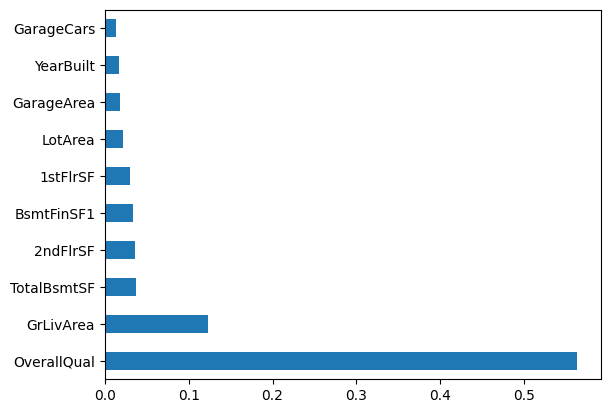

In [11]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind='barh')

In [12]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RMSE:", rmse)

RMSE: 29159.325958926194


In [14]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [15]:
from sklearn.metrics import r2_score

print("Linear Regression R2:", r2_score(y_test, y_pred))
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Linear Regression R2: 0.8226775450640382
Decision Tree R2: 0.7823623688106879
Random Forest R2: 0.8891486140990713


Conclusion:
Among the models tested, Random Forest performed the best with the highest R² score, indicating better prediction accuracy. Linear Regression showed lower performance due to the complex nature of housing data. This project demonstrates the effectiveness of ensemble methods in regression tasks.